# Test: Simple Quadrupole Trap

This notebook tests the disk-based multipole extraction on a **simple, ideal 4-electrode quadrupole** to verify the method works before tackling complex geometries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("✓ Imports complete")


✓ Imports complete


In [2]:
# Create simple 4-electrode quadrupole
# Four electrodes at corners: two at +V, two at -V (diagonal pairs)
# This creates a saddle potential with RF null at origin

def create_simple_quadrupole():
    electrodes = []
    d = 1.0  # Distance from center to electrode
    w = 0.15  # Electrode width
    
    # Diagonal 1: +1V  
    electrodes.append((d-w, d+w, d-w, d+w, 1.0))      # Top-right
    electrodes.append((-d-w, -d+w, -d-w, -d+w, 1.0))  # Bottom-left
    
    # Diagonal 2: -1V
    electrodes.append((-d-w, -d+w, d-w, d+w, -1.0))   # Top-left
    electrodes.append((d-w, d+w, -d-w, -d+w, -1.0))   # Bottom-right
    
    return electrodes

electrodes = create_simple_quadrupole()
print(f"✓ Created quadrupole with {len(electrodes)} electrodes")


✓ Created quadrupole with 4 electrodes


In [3]:
# Solve Laplace equation with SOR
def solve_laplace_sor(electrodes, grid_size=401, domain=2.5, omega=1.9, max_iter=20000, tol=1e-7):
    x = np.linspace(-domain, domain, grid_size)
    y = np.linspace(-domain, domain, grid_size)
    V = np.zeros((grid_size, grid_size))
    is_elec = np.zeros_like(V, dtype=bool)
    
    # Mark electrodes
    for i in range(grid_size):
        for j in range(grid_size):
            for (xmin, xmax, ymin, ymax, Vval) in electrodes:
                if xmin <= x[j] <= xmax and ymin <= y[i] <= ymax:
                    is_elec[i, j] = True
                    V[i, j] = Vval
                    break
    
    # SOR iteration
    print("Solving Laplace equation...")
    for it in range(max_iter):
        V_old = V.copy()
        for i in range(1, grid_size-1):
            for j in range(1, grid_size-1):
                if not is_elec[i, j]:
                    V_new = 0.25 * (V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
                    V[i, j] = (1-omega)*V[i,j] + omega*V_new
        
        if it % 2000 == 0:
            err = np.max(np.abs(V - V_old))
            print(f"  Iter {it:5d}, error: {err:.2e}")
            if err < tol:
                print(f"  ✓ Converged at iteration {it}")
                break
    
    return V, x, y

V, x, y = solve_laplace_sor(electrodes, grid_size=401, domain=2.5)
print(f"✓ Solution complete, grid size: {V.shape}")


Solving Laplace equation...
  Iter     0, error: 9.05e-01
  Iter  2000, error: 1.25e-07
  Iter  4000, error: 3.02e-10
  ✓ Converged at iteration 4000
✓ Solution complete, grid size: (401, 401)


In [4]:
# Extract multipoles using DISK-BASED fitting
def extract_multipoles_disk(V, x, y, center, r_fit, R0=1.0, n_max=8):
    """Extract multipoles by fitting over entire disk (not just a ring!)"""
    X, Y = np.meshgrid(x, y, indexing='xy')
    Xc = X - center[0]
    Yc = Y - center[1]
    R = np.hypot(Xc, Yc)
    
    # Disk mask - include ALL points within radius
    mask = (R <= r_fit) & (np.abs(V) < 0.99)  # Exclude electrode points
    
    xs = Xc[mask].ravel()
    ys = Yc[mask].ravel()
    vs = V[mask].ravel()
    
    print(f"  Fitting with {len(vs)} points in disk (r={r_fit:.3f})")
    
    # Build design matrix: columns are Re(z^n) and Im(z^n)
    z = xs + 1j*ys
    A_matrix = []
    for n in range(n_max + 1):
        z_pow = z**n / (R0**n)
        A_matrix.append(np.real(z_pow))
        A_matrix.append(np.imag(z_pow))
    
    A_matrix = np.array(A_matrix).T  # Shape: (n_points, 2*(n_max+1))
    
    # Least-squares fit
    coeffs, residuals, rank, s = np.linalg.lstsq(A_matrix, vs, rcond=None)
    
    # Extract multipole coefficients
    multipoles = {'V0': coeffs[0]}
    for n in range(1, n_max+1):
        A_n = coeffs[2*n]
        B_n = coeffs[2*n+1]
        p_n = np.hypot(A_n, B_n)
        multipoles[f'A{n}'] = A_n
        multipoles[f'B{n}'] = B_n
        multipoles[f'p{n}'] = p_n
    
    # Calculate ratios p_n/p_2
    p2 = multipoles.get('p2', 1e-15)
    if p2 < 1e-15: p2 = 1e-15
    
    ratios = {f'p{n}/p2': multipoles[f'p{n}']/p2 for n in range(3, n_max+1)}
    
    return multipoles, ratios

# Extract multipoles with small fitting radius
center = (0.0, 0.0)
R0 = 1.0  # Distance to electrodes
r_fit = 0.3  # Fit disk radius (30% of R0)

print("\nExtracting multipoles...")
multipoles, ratios = extract_multipoles_disk(V, x, y, center, r_fit=r_fit, R0=R0, n_max=8)



Extracting multipoles...
  Fitting with 1791 points in disk (r=0.300)


In [5]:
# Print results
print("\n" + "="*70)
print("MULTIPOLE ANALYSIS RESULTS")
print("="*70)
print(f"\n{'Order':<10} {'|p_n|':<15} {'p_n/p_2':<15}")
print("-" * 45)

for n in range(1, 9):
    p_n = multipoles.get(f'p{n}', 0.0)
    if n >= 3:
        ratio = ratios.get(f'p{n}/p2', 0.0)
        print(f"p{n:<9} {p_n:<15.6e} {ratio:<15.6e}")
    else:
        print(f"p{n:<9} {p_n:<15.6e} {'--':<15}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print(f"p1 (dipole):   Should be ~0 (trap centered)")
print(f"p2 (quadrupole): Main trapping term")
print(f"p3-p8:         Should be ~0 for ideal quadrupole")
print(f"               Non-zero values = field imperfections")
print("\n✓ For ideal 4-electrode quadrupole:")
print("  p_n/p_2 should be < 0.01 for n=3,4,5,6,7,8")



MULTIPOLE ANALYSIS RESULTS

Order      |p_n|           p_n/p_2        
---------------------------------------------
p1         8.453934e-03    --             
p2         4.751248e-01    --             
p3         2.402162e-05    5.055856e-05   
p4         5.011807e-05    1.054840e-04   
p5         2.291664e-03    4.823290e-03   
p6         4.359306e-02    9.175075e-02   
p7         9.496328e-06    1.998702e-05   
p8         1.534558e-05    3.229800e-05   

INTERPRETATION:
p1 (dipole):   Should be ~0 (trap centered)
p2 (quadrupole): Main trapping term
p3-p8:         Should be ~0 for ideal quadrupole
               Non-zero values = field imperfections

✓ For ideal 4-electrode quadrupole:
  p_n/p_2 should be < 0.01 for n=3,4,5,6,7,8


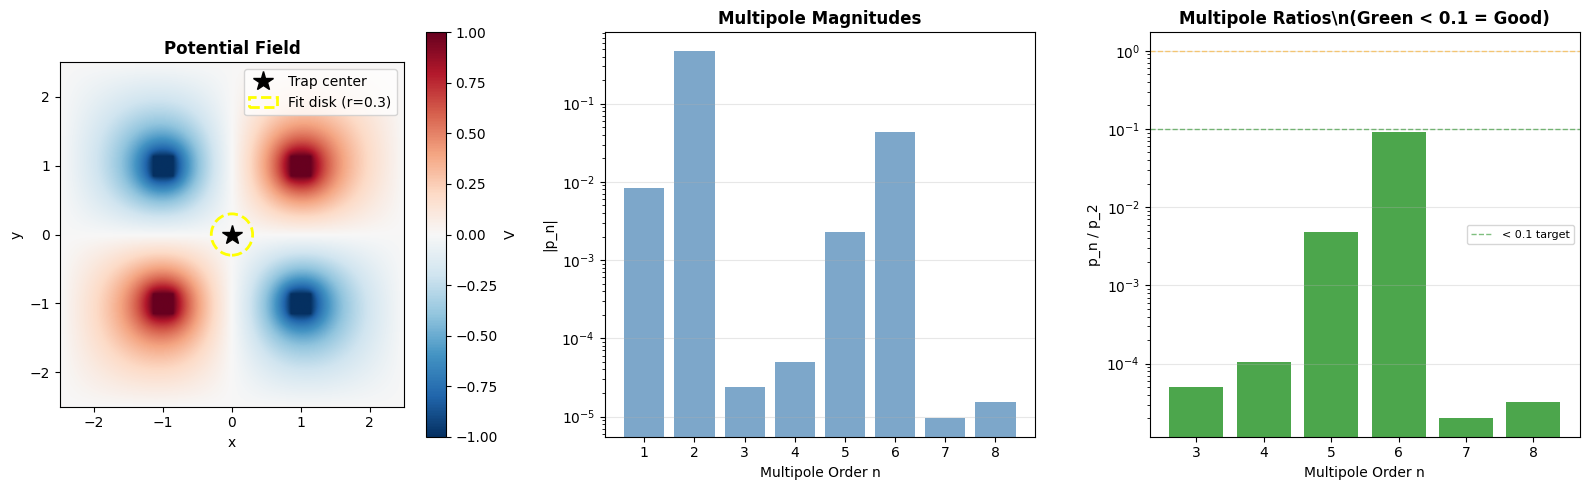


✓ Analysis complete!


In [6]:
# Visualize
fig = plt.figure(figsize=(16, 5))

# 1) Potential field
ax1 = plt.subplot(1, 3, 1)
extent = [x[0], x[-1], y[0], y[-1]]
im = ax1.imshow(V, extent=extent, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
ax1.plot(0, 0, 'k*', ms=15, label='Trap center')
circle = plt.Circle((0, 0), r_fit, fill=False, color='yellow', lw=2, ls='--', label=f'Fit disk (r={r_fit})')
ax1.add_patch(circle)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Potential Field', fontweight='bold')
ax1.legend()
plt.colorbar(im, ax=ax1, label='V')

# 2) Multipole magnitudes
ax2 = plt.subplot(1, 3, 2)
orders = np.arange(1, 9)
mags = [multipoles.get(f'p{n}', 0) for n in orders]
ax2.bar(orders, mags, alpha=0.7, color='steelblue')
ax2.set_xlabel('Multipole Order n')
ax2.set_ylabel('|p_n|')
ax2.set_yscale('log')
ax2.set_title('Multipole Magnitudes', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticks(orders)

# 3) Ratios p_n/p_2
ax3 = plt.subplot(1, 3, 3)
ratio_orders = np.arange(3, 9)
ratio_vals = [ratios.get(f'p{n}/p2', 0) for n in ratio_orders]
colors = ['green' if r < 0.1 else 'orange' if r < 1.0 else 'red' for r in ratio_vals]
ax3.bar(ratio_orders, ratio_vals, alpha=0.7, color=colors)
ax3.set_xlabel('Multipole Order n')
ax3.set_ylabel('p_n / p_2')
ax3.set_yscale('log')
ax3.set_title('Multipole Ratios\\n(Green < 0.1 = Good)', fontweight='bold')
ax3.grid(alpha=0.3, axis='y')
ax3.set_xticks(ratio_orders)
ax3.axhline(0.1, color='green', ls='--', lw=1, alpha=0.5, label='< 0.1 target')
ax3.axhline(1.0, color='orange', ls='--', lw=1, alpha=0.5)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")
